**Task 1 – Data Visualisation in python**


You have recently secured a position as a data visualisation creator at a Data Insights research facility. Your line manager has asked you to **build and complete appropriate visualisations on the performance of various bakery sales around Europe**: the data set to be used is Data Visualisation – COM7021- [4566] Bakery – supporting document.xlsx.   
The visualisations are to be presented to the company’s board as part of the proposed strategy to **improve regional profits** through a process of **overhead reductions** and improved revenue for each city. The company’s European managers are particularly interested in determining whether **location** or **type of confectionery sold** is affecting **profitability**, in case European store closures are requested from board members.  
From your findings **compose appropriate visualisations, including a fully immersive European interactive dashboard**, which will formulate a **compelling narrative** that will **inform** your identified **targeted audience** of the **solution you propose**. The full investigation is to be
conducted in Python. Ensure your Python code is submitted as an appendix to the report.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import scipy
from sklearn.utils import resample
import warnings
from sklearn import linear_model
plt.style.use('default')
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"
warnings.filterwarnings('ignore')

In [103]:
from google.colab import drive
drive.mount('/content/drive')

df_raw = pd.read_excel('/content/drive/MyDrive/Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [104]:
df_raw.head()

,Date,City,Confectionary,Units Sold,Revenue(£),Cost(£),Profit(£)
0,2002-11-11,London,Biscuit,1118.0,5590.0,2459.6,3130.4
1,2002-07-05,London,Biscuit,708.0,3540.0,1557.6,1982.4
2,2001-10-31,London,Biscuit,1269.0,6345.0,2791.8,3553.2
3,2004-09-13,London,Biscuit,1631.0,8155.0,3588.2,4566.8
4,2004-03-10,London,Biscuit,2240.0,11200.0,4928.0,6272.0


In [105]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1001 non-null   datetime64[ns]
 1   City           1001 non-null   object        
 2   Confectionary  1001 non-null   object        
 3   Units Sold     996 non-null    float64       
 4   Revenue(£)     992 non-null    float64       
 5   Cost(£)        992 non-null    float64       
 6   Profit(£)      998 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 54.9+ KB


In [106]:
df_raw.isnull().sum()

,0
Date,0
City,0
Confectionary,0
Units Sold,5
Revenue(£),9
Cost(£),9
Profit(£),3


In [107]:
df_raw.describe()

,Date,Units Sold,Revenue(£),Cost(£),Profit(£)
count,1001,996.000000,992.000000,992.000000,998.000000
mean,2002-11-19 10:54:32.727272832,1633.360442,6847.601815,2820.190877,4012.076052
min,2000-01-02 00:00:00,200.000000,200.000000,40.000000,160.000000
25%,2001-05-12 00:00:00,923.000000,2993.000000,1204.000000,1872.400000
50%,2002-11-10 00:00:00,1530.500000,5967.000000,2456.800000,3459.000000
75%,2004-04-25 00:00:00,2300.000000,9505.000000,3977.625000,5445.000000
max,2005-12-28 00:00:00,4493.000000,23988.000000,10994.500000,13479.000000
std,NaN,876.356045,4699.184062,2073.969135,2648.166312


In [108]:
df_raw['Confectionary'].unique()

array(['Biscuit', 'Biscuit Nut', 'Choclate Chunk', 'Caramel nut',
       'Caramel', 'Plain', 'Chocolate Chunk', 'Caramel Nut'], dtype=object)

In [109]:
df_raw['City'].unique()

array(['London', 'Paris', 'Bonn', 'Seville', 'Napoli'], dtype=object)

In [110]:
# Rename the 'Confectionary' column to 'Confectionery' in df_raw
df_raw = df_raw.rename(columns={'Confectionary': 'Confectionery'})

# Fix spelling + standardisation for specific confectionery names
df_raw['Confectionery'] = df_raw['Confectionery'].replace({
    'Choclate Chunk': 'Chocolate Chunk',
    'Caramel nut': 'Caramel Nut'
})

In [111]:
df_raw.isnull().sum()

,0
Date,0
City,0
Confectionery,0
Units Sold,5
Revenue(£),9
Cost(£),9
Profit(£),3


In [112]:
# Display rows with any missing values
missing_rows = df_raw[df_raw.isnull().any(axis=1)]
display(missing_rows.head(1000))

,Date,City,Confectionery,Units Sold,Revenue(£),Cost(£),Profit(£)
19,2005-12-07,London,Biscuit Nut,819.0,3276.0,NaN,2047.50
30,2000-09-25,London,Chocolate Chunk,NaN,5622.0,2342.50,3279.50
36,2003-05-16,London,Chocolate Chunk,2109.0,6327.0,NaN,3690.75
48,2005-03-29,London,Caramel Nut,1582.0,9492.0,NaN,5141.50
86,2000-10-10,Paris,Plain,1899.0,NaN,379.80,1519.20
111,2001-01-12,Paris,Biscuit,1393.0,NaN,3064.60,NaN
138,2002-06-08,Paris,Chocolate Chunk,575.0,NaN,718.75,1006.25
175,2003-02-18,Bonn,Caramel,1095.0,NaN,2190.00,3285.00
202,2003-10-19,Bonn,Plain,NaN,766.0,153.20,612.80
228,2005-01-26,Bonn,Biscuit Nut,280.0,1120.0,NaN,700.00


The output above shows the first few rows that contain at least one missing value in any of their columns. This helps in understanding the context of these missing entries. You can inspect specific rows and columns to decide on an imputation strategy.

In [113]:
# Fill Profit when Revenue and Cost exist
df_raw.loc[
    df_raw['Profit(£)'].isnull() &
    df_raw['Revenue(£)'].notnull() &
    df_raw['Cost(£)'].notnull(),
    'Profit(£)'
] = df_raw['Revenue(£)'] - df_raw['Cost(£)']


# Fill Revenue when Cost and Profit exist
df_raw.loc[
    df_raw['Revenue(£)'].isnull() &
    df_raw['Cost(£)'].notnull() &
    df_raw['Profit(£)'].notnull(),
    'Revenue(£)'
] = df_raw['Cost(£)'] + df_raw['Profit(£)']


# Fill Cost when Revenue and Profit exist
df_raw.loc[
    df_raw['Cost(£)'].isnull() &
    df_raw['Revenue(£)'].notnull() &
    df_raw['Profit(£)'].notnull(),
    'Cost(£)'
] = df_raw['Revenue(£)'] - df_raw['Profit(£)']


# Finally, fill remaining missing values using median
df_raw['Revenue(£)'].fillna(df_raw['Revenue(£)'].median(), inplace=True)
df_raw['Cost(£)'].fillna(df_raw['Cost(£)'].median(), inplace=True)
df_raw['Profit(£)'].fillna(df_raw['Profit(£)'].median(), inplace=True)

# Units Sold
df_raw['Units Sold'].fillna(df_raw['Units Sold'].median(), inplace=True)


In [114]:
df_raw.isnull().sum()

,0
Date,0
City,0
Confectionery,0
Units Sold,0
Revenue(£),0
Cost(£),0
Profit(£),0


In [115]:
df_raw.head(10)

,Date,City,Confectionery,Units Sold,Revenue(£),Cost(£),Profit(£)
0,2002-11-11,London,Biscuit,1118.0,5590.0,2459.6,3130.4
1,2002-07-05,London,Biscuit,708.0,3540.0,1557.6,1982.4
2,2001-10-31,London,Biscuit,1269.0,6345.0,2791.8,3553.2
3,2004-09-13,London,Biscuit,1631.0,8155.0,3588.2,4566.8
4,2004-03-10,London,Biscuit,2240.0,11200.0,4928.0,6272.0
5,2004-05-29,London,Biscuit,3521.0,17605.0,7746.2,9858.8
6,2000-10-30,London,Biscuit,707.0,3535.0,1555.4,1979.6
7,2005-04-30,London,Biscuit,2734.0,13670.0,6014.8,7655.2
8,2002-03-09,London,Biscuit,1659.0,8295.0,3649.8,4645.2
9,2000-08-05,London,Biscuit,888.0,4440.0,1953.6,2486.4


In [116]:
df_raw.duplicated().sum()

np.int64(0)

In [117]:
import plotly.graph_objects as go
import pandas as pd

# Function to convert hex to rgba
def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip('#')
    lv = len(hex_color)
    rgb = tuple(int(hex_color[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
    return f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha})'

# ── Uses df_raw (your actual cleaned dataset) ───────────────────────
# No synthetic data — all distributions come directly from real transactions

PALETTE = {
    'Revenue(£)': '#4C78A8',
    'Cost(£)':    '#E15759',
    'Profit(£)':  '#59A14F',
}

TEXT_MAIN = '#1E293B'
TEXT_SUB  = '#64748B'
GRID      = '#E2E8F0'

cities = sorted(df_raw['City'].dropna().unique())

fig = go.Figure()

for metric, colour in PALETTE.items():
    fig.add_trace(go.Box(
        x=df_raw['City'],
        y=df_raw[metric],
        name=metric,
        marker_color=colour,
        line=dict(color=colour, width=1.8),
        fillcolor=hex_to_rgba(colour, 0.15),        # 15% opacity fill
        boxpoints='outliers',           # only show outlier dots
        marker=dict(
            size=5,
            opacity=0.7,
            line=dict(width=1, color=colour)
        ),
        whiskerwidth=0.5,
        offsetgroup=metric,
        legendgroup=metric,
        hovertemplate=(
            '<b>%{x}</b><br>'
            f'{metric}: ' + '£%{y:,.0f}<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(
        text=(
            '<b>City-Level Financial Distribution with Outlier Analysis</b>'
            '<br><span style="font-size:14px;color:#94A3B8;">'
            'Distribution of Revenue, Cost, and Profit across European Cities</span>'
        ),
        x=0.04, xanchor='left',
        y=0.97, yanchor='top',
        font=dict(family='Arial', size=20, color=TEXT_MAIN)
    ),
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#F8FAFC',
    boxmode='group',
    height=600,
    legend=dict(
        orientation='h',
        x=1, xanchor='right',
        y=1.06, yanchor='top',
        bgcolor='rgba(0,0,0,0)',
        font=dict(family='Arial', size=12, color=TEXT_SUB),
        title=dict(text='Metric  ', font=dict(color=TEXT_SUB, size=11)),
        itemsizing='constant',
    ),
    xaxis=dict(
        title=dict(text='City', font=dict(family='Arial', size=13, color=TEXT_SUB)),
        tickfont=dict(family='Arial', size=13, color=TEXT_MAIN),
        showgrid=False,
        zeroline=False,
        linecolor=GRID,
        linewidth=1,
        tickangle=0,
    ),
    yaxis=dict(
        title=dict(text='Amount (£)', font=dict(family='Arial', size=13, color=TEXT_SUB)),
        tickprefix='£',
        tickfont=dict(family='Arial', size=12, color=TEXT_SUB),
        gridcolor=GRID,
        griddash='dot',
        gridwidth=1,
        zeroline=False,
        linecolor=GRID,
    ),
    hovermode='closest',
    hoverlabel=dict(
        bgcolor='#FFFFFF',
        bordercolor=GRID,
        font=dict(family='Arial', size=12, color=TEXT_MAIN)
    ),
    margin=dict(l=70, r=40, t=90, b=60),
    font=dict(family='Arial', color=TEXT_MAIN),
)

fig.show()

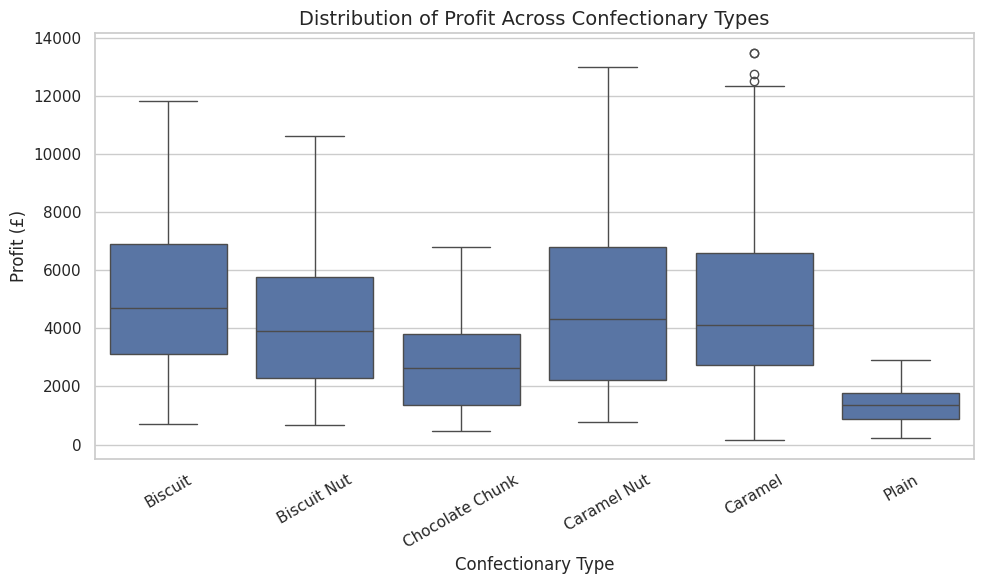

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x='Confectionery',
    y='Profit(£)'
)

plt.title('Distribution of Profit Across Confectionary Types', fontsize=14)
plt.xlabel('Confectionary Type', fontsize=12)
plt.ylabel('Profit (£)', fontsize=12)
color_discrete_sequence=px.colors.qualitative.Set2
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("Boxplot_Profit_Outliers.jpg", dpi=300)
plt.show()

# ***Exploratory Data Analysis (EDA)***

In [119]:
#Checking Outliers-2
Q1 = df_raw['Profit(£)'].quantile(0.25)
Q3 = df_raw['Profit(£)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_raw[(df_raw['Profit(£)'] < lower_bound) | (df_raw['Profit(£)'] > upper_bound)]

print(len(outliers))

20


In [120]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── Data prep (mirrors your existing pipeline) ────────────────────────────────
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

city_monthly = (
    df_raw
    .groupby(['City', pd.Grouper(key='Date', freq='ME')])['Profit(£)']
    .sum()
    .reset_index()
    .sort_values(['City', 'Date'])
)

city_monthly['Profit_3M_MA'] = (
    city_monthly
    .groupby('City')['Profit(£)']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# ── Palette ───────────────────────────────────────────────────────────────────
CITY_COLORS = {
    'London':  '#3B82F6',
    'Paris':   '#F59E0B',
    'Bonn':    '#10B981',
    'Napoli':  '#F43F5E',
    'Seville': '#8B5CF6',
}

TEXT_MAIN = '#1E293B'
TEXT_SUB  = '#64748B'
GRID      = '#E2E8F0'

# ── Build figure ──────────────────────────────────────────────────────────────
fig = go.Figure()

for city, grp in city_monthly.groupby('City'):
    colour = CITY_COLORS.get(city, '#888888')
    grp = grp.sort_values('Date')

    # Raw monthly profit — faint background bars
    fig.add_trace(go.Bar(
        x=grp['Date'],
        y=grp['Profit(£)'],
        name=f'{city} (monthly)',
        marker_color=colour,
        opacity=0.18,
        showlegend=False,
        hovertemplate=(
            f'<b>{city}</b><br>'
            'Month: %{x|%b %Y}<br>'
            'Monthly Profit: £%{y:,.0f}<extra></extra>'
        )
    ))

    # 3-month moving average line
    fig.add_trace(go.Scatter(
        x=grp['Date'],
        y=grp['Profit_3M_MA'],
        name=city,
        mode='lines+markers',
        line=dict(color=colour, width=2.5),
        marker=dict(size=5, color=colour,
                    line=dict(width=1.5, color='white')),
        hovertemplate=(
            f'<b>{city}</b><br>'
            'Month: %{x|%b %Y}<br>'
            '3M Moving Avg: £%{y:,.0f}<extra></extra>'
        )
    ))

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#F8FAFC',
    height=560,
    barmode='overlay',

    title=dict(
        text=(
            '<b>Profit Trends Across European Cities</b>'
            '<br><span style="font-size:13px;color:#94A3B8;">'
            '3-Month Moving Average · Monthly bars shown for reference</span>'
        ),
        x=0.04, xanchor='left',
        y=0.97, yanchor='top',
        font=dict(family='Georgia, serif', size=20, color=TEXT_MAIN)
    ),

    legend=dict(
        orientation='h',
        x=0.5, xanchor='center',
        y=-0.18, yanchor='top',
        bgcolor='rgba(0,0,0,0)',
        font=dict(family='Georgia, serif', size=12, color=TEXT_SUB),
        title=dict(text='City  ', font=dict(color=TEXT_SUB, size=11)),
        itemsizing='constant',
        traceorder='normal'
    ),

    xaxis=dict(
        title=dict(text='Date', font=dict(family='Georgia, serif', size=13, color=TEXT_SUB)),
        tickfont=dict(family='Georgia, serif', size=12, color=TEXT_MAIN),
        showgrid=False,
        zeroline=False,
        linecolor=GRID,
        linewidth=1,
        tickangle=-30,
        dtick='M6',
        tickformat='%b %Y',
        rangeslider=dict(visible=True, thickness=0.04, bgcolor='#F1F5F9'),
    ),

    yaxis=dict(
        title=dict(
            text='Profit (£) — 3-Month Moving Average',
            font=dict(family='Georgia, serif', size=13, color=TEXT_SUB)
        ),
        tickprefix='£',
        tickfont=dict(family='Georgia, serif', size=12, color=TEXT_SUB),
        gridcolor=GRID,
        griddash='dot',
        gridwidth=1,
        zeroline=True,
        zerolinecolor='#CBD5E1',
        zerolinewidth=1.5,
        linecolor=GRID,
    ),

    # Range selector buttons
    xaxis_rangeselector=dict(
        buttons=[
            dict(count=6,  label='6M',  step='month', stepmode='backward'),
            dict(count=1,  label='1Y',  step='year',  stepmode='backward'),
            dict(count=2,  label='2Y',  step='year',  stepmode='backward'),
            dict(label='All', step='all'),
        ],
        bgcolor='#F1F5F9',
        activecolor='#3B82F6',
        font=dict(family='Georgia, serif', size=11, color=TEXT_MAIN),
        x=0.0, y=1.08
    ),

    hovermode='x unified',
    hoverlabel=dict(
        bgcolor='#FFFFFF',
        bordercolor=GRID,
        font=dict(family='Georgia, serif', size=12, color=TEXT_MAIN),
        namelength=-1
    ),

    margin=dict(l=70, r=40, t=100, b=100),
    font=dict(family='Georgia, serif', color=TEXT_MAIN),
)

fig.show()

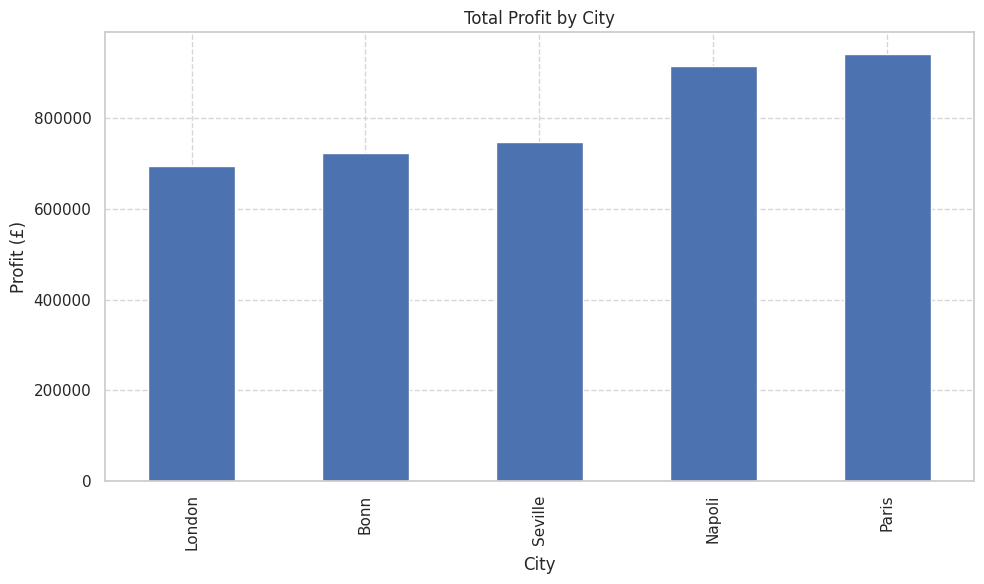

In [121]:

#Profit by City
df_raw.groupby('City')['Profit(£)'].sum().sort_values().plot(kind='bar', figsize=(10,6))
plt.title('Total Profit by City')
plt.ylabel('Profit (£)')
plt.grid(True, linestyle='--', alpha=0.8)
color_discrete_sequence=px.colors.qualitative.Set2
plt.tight_layout()
plt.savefig("Profit_by_City.jpg", dpi=800)
plt.show()

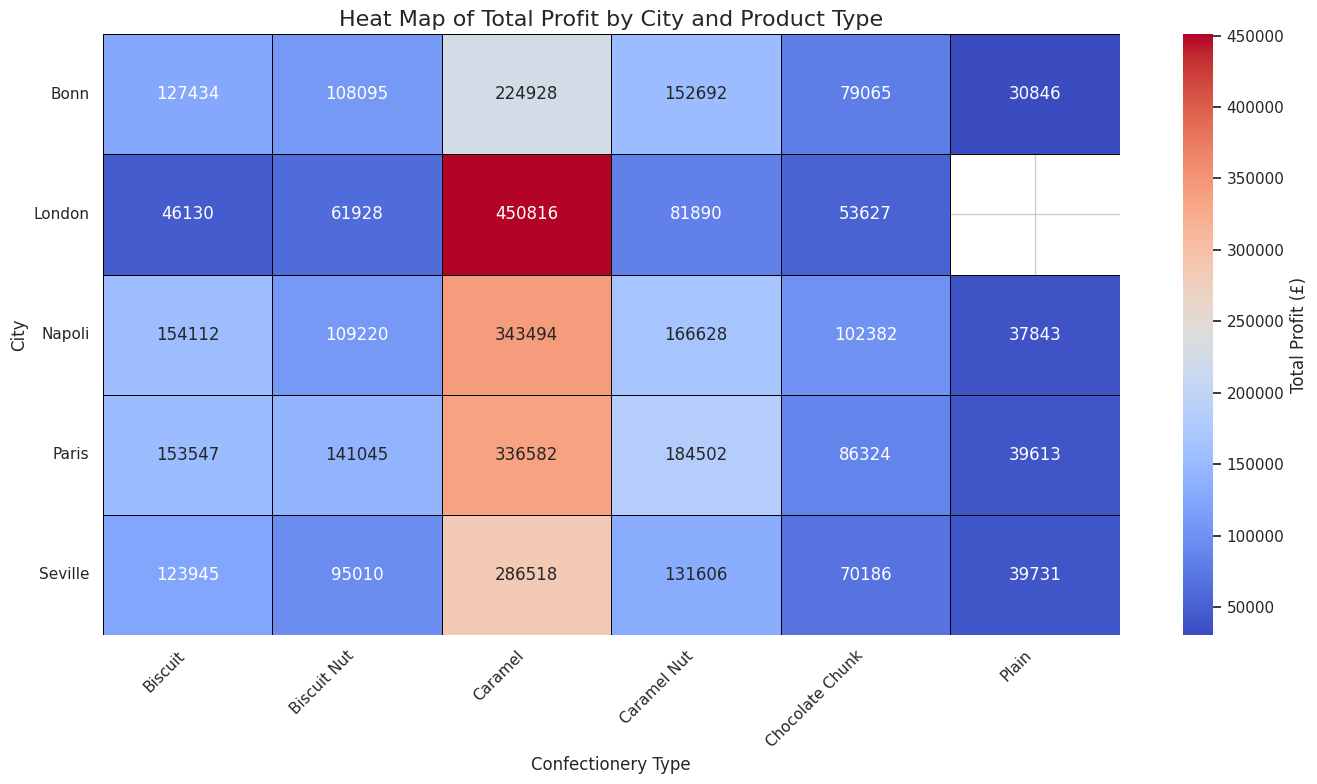

In [88]:
#Heatmap (Correlation)-Which factor correlates strongest with Profit?

import matplotlib.pyplot as plt
import seaborn as sns

# City + Product Combined

pivot = df_raw.pivot_table(
    values='Profit(£)',
    index='City',
    columns='Confectionery',
    aggfunc='sum'
)

plt.figure(figsize=(14, 8)) # Increased figure size for better readability
sns.heatmap(pivot,
            annot=True,
            fmt=".0f",
            cmap='coolwarm',
            linewidths=.5, # Add lines between cells
            linecolor='black', # Color of the lines
            cbar_kws={'label': 'Total Profit (£)'}) # Add a label to the color bar

plt.title('Heat Map of Total Profit by City and Product Type', fontsize=16) # Enhanced title font size
plt.xlabel('Confectionery Type', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better fit
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
color_discrete_sequence=px.colors.qualitative.Set2
plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping
plt.savefig("Profit_by_City_and_Product_professional.jpg", dpi=1000) # Save with a new name to distinguish
plt.show()

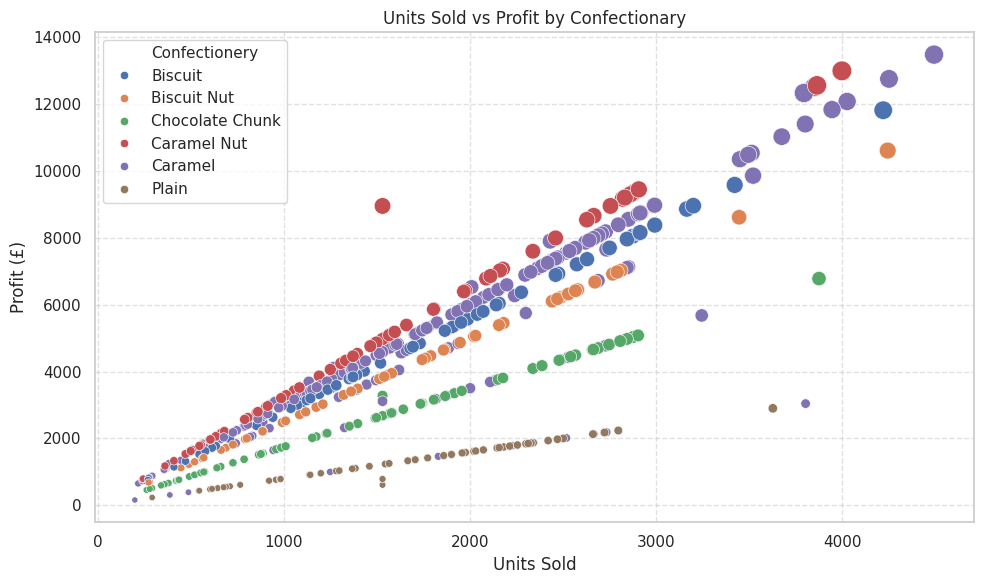

In [89]:
#Units_Sold_vs_Profit_Clean-1
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Units Sold',
    y='Profit(£)',
    hue='Confectionery',
    size='Revenue(£)',
    sizes=(20, 200),
    legend='brief',   # ☗ limits legend
    data=df_raw
)

plt.title('Units Sold vs Profit by Confectionary')
plt.xlabel('Units Sold')
plt.ylabel('Profit (£)')

# Remove size legend (only keep color legend)
handles, labels = plt.gca().get_legend_handles_labels()

# Keep only confectionary labels
plt.legend(handles[:len(df_raw['Confectionery'].unique())+1],
           labels[:len(df_raw['Confectionery'].unique())+1],)
color_discrete_sequence=px.colors.qualitative.Set2
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Units_Sold_vs_Profit_Clean_1.jpg", dpi=300)
plt.show()

In [90]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ---------- Helper formatting ----------
def compact_currency(x):
    if abs(x) >= 1_000_000:
        return f"£{x/1_000_000:.2f}M"
    elif abs(x) >= 1_000:
        return f"£{x/1_000:.1f}K"
    return f"£{x:,.0f}"

def get_city_metrics(df, city_name="All"):
    if city_name == "All":
        filtered = df.copy()
        label = "European Portfolio"
    else:
        filtered = df[df["City"] == city_name].copy()
        label = city_name

    revenue = filtered["Revenue(£)"].sum()
    cost = filtered["Cost(£)"].sum()
    profit = filtered["Profit(£)"].sum()
    margin = (profit / revenue * 100) if revenue > 0 else 0
    cost_ratio = (cost / revenue * 100) if revenue > 0 else 0

    return {
        "label": label,
        "revenue": revenue,
        "cost": cost,
        "profit": profit,
        "margin": margin,
        "cost_ratio": cost_ratio
    }

def build_kpi_text(metrics):
    return (
        f"<b style='font-size:18px'>{metrics['label']}</b><br>"
        f"<span style='font-size:12px;color:#6b7280'>Operational summary</span><br><br>"

        f"<span style='font-size:12px;color:#6b7280'>Revenue</span><br>"
        f"<b style='font-size:18px;color:#111827'>{compact_currency(metrics['revenue'])}</b><br><br>"

        f"<span style='font-size:12px;color:#6b7280'>Cost</span><br>"
        f"<b style='font-size:18px;color:#111827'>{compact_currency(metrics['cost'])}</b><br><br>"

        f"<span style='font-size:12px;color:#6b7280'>Profit</span><br>"
        f"<b style='font-size:18px;color:#111827'>{compact_currency(metrics['profit'])}</b><br><br>"

        f"<span style='font-size:12px;color:#6b7280'>Profit Margin</span><br>"
        f"<b style='font-size:18px;color:#111827'>{metrics['margin']:.1f}%</b><br><br>"

        f"<span style='font-size:12px;color:#6b7280'>Cost Ratio</span><br>"
        f"<b style='font-size:18px;color:#111827'>{metrics['cost_ratio']:.1f}%</b>"
    )

# ---------- Prepare city list ----------
cities = ["All"] + sorted(df_raw["City"].dropna().unique().tolist())

# ---------- Create figure ----------
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.28, 0.72],
    specs=[[{"type": "domain"}, {"type": "waterfall"}]],
    horizontal_spacing=0.25
)

# ---------- Add waterfall traces ----------
for city in cities:
    m = get_city_metrics(df_raw, city)

    revenue_pct = 100
    cost_pct = (m["cost"] / m["revenue"] * 100) if m["revenue"] > 0 else 0
    profit_pct = (m["profit"] / m["revenue"] * 100) if m["revenue"] > 0 else 0

    fig.add_trace(
        go.Waterfall(
            name=city,
            orientation="v",
            measure=["absolute", "relative", "total"],
            x=["Revenue", "Cost", "Profit"],
            y=[m["revenue"], -m["cost"], 0],
            text=[
                compact_currency(m["revenue"]),
                compact_currency(m["cost"]),
                compact_currency(m["profit"])
            ],
            textposition="outside",
            connector={"line": {"color": "rgba(75,85,99,0.7)", "width": 1.2}},
            increasing={"marker": {"color": "#4C78A8"}},
            decreasing={"marker": {"color": "#E15759"}},
            totals={"marker": {"color": "#2F5D50"}},
            customdata=[
                [revenue_pct],
                [cost_pct],
                [profit_pct]
            ],
            hovertemplate=(
                "<b>%{x}</b><br>"
                "Amount: %{text}<br>"
                "Share of Revenue: %{customdata[0]:.1f}%<extra></extra>"
            ),
            visible=(city == "All")
        ),
        row=1,
        col=2
    )

# ---------- Add default KPI panel ----------
default_metrics = get_city_metrics(df_raw, "All")

fig.add_annotation(
    x=0.12,
    y=0.53,
    xref="paper",
    yref="paper",
    text=build_kpi_text(default_metrics),
    showarrow=False,
    align="left",
    bgcolor="#F8FAFC",
    bordercolor="#D1D5DB",
    borderwidth=1,
    borderpad=18,
    font=dict(family="Arial", size=12, color="#111827")
)

# ---------- Dropdown ----------
buttons = []
for i, city in enumerate(cities):
    m = get_city_metrics(df_raw, city)

    visibility = [False] * len(cities)
    visibility[i] = True

    buttons.append(
        dict(
            label=city,
            method="update",
            args=[
                {"visible": visibility},
                {
                    "annotations": [
                        dict(
                            x=0.82,
                            y=0.53,
                            xref="paper",
                            yref="paper",
                            text=build_kpi_text(m),
                            showarrow=False,
                            align="left",
                            bgcolor="#F8FAFC",
                            bordercolor="#D1D5DB",
                            borderwidth=1,
                            borderpad=18,
                            font=dict(family="Arial", size=13, color="#111827")
                        )
                    ]
                }
            ]
        )
    )

# ---------- Layout ----------
fig.update_layout(
    title={
        "text": (
            "Bakery Financial Performance Dashboard"
            "<br><span style='font-size:14px;color:#6b7280'>"
            "Interactive revenue-cost-profit breakdown by city"
            "</span>"
        ),
        "x": 0.54,
        "xanchor": "left"
    },
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.04,
            xanchor="left",
            y=0.88,
            yanchor="top",
            bgcolor="white",
            bordercolor="#D1D5DB",
            borderwidth=1,
            font=dict(size=12, color="#111827"),
            pad={"r": 8, "t": 4}
        )
    ],
    paper_bgcolor="white",
    plot_bgcolor="#F8FAFC",
    font=dict(family="Arial", color="#111827"),
    height=620,
    margin=dict(t=120, l=40, r=40, b=50),
    showlegend=False
)

fig.update_yaxes(
    title_text="Amount (£)",
    gridcolor="#E5E7EB",
    zerolinecolor="#9CA3AF",
    tickprefix="£",
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Financial Components",
    row=1,
    col=2
)
color_discrete_sequence=px.colors.qualitative.Set2
plt.tight_layout()
plt.savefig("Bakery_Waterfall_Dashboard.jpg", dpi=1000)
fig.show()

# Optional save
# fig.write_html("Bakery_Waterfall_Dashboard.html")

<Figure size 640x480 with 0 Axes>

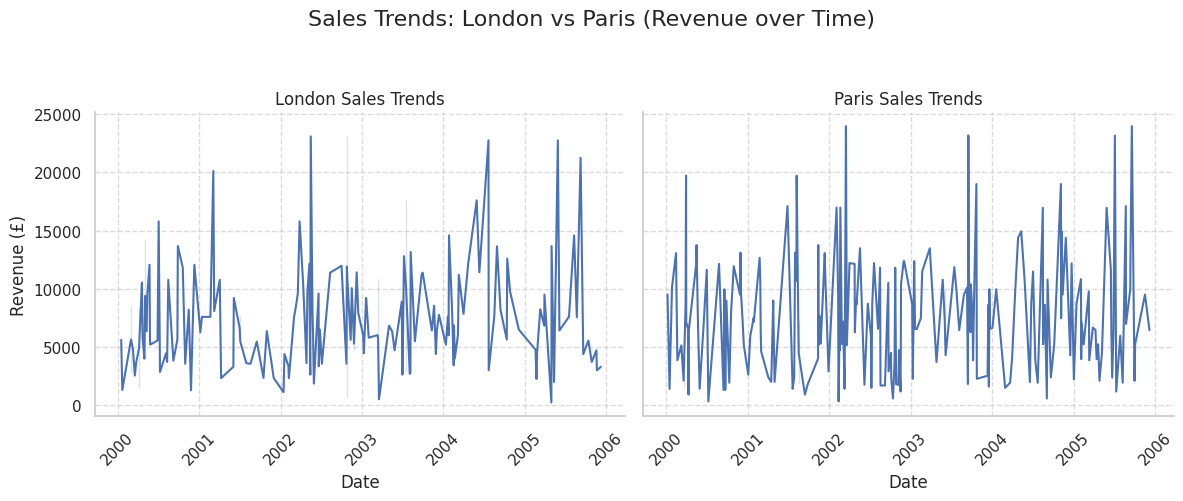

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' column is in datetime format
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Filter for London and Paris
cities_to_compare = ['London', 'Paris']
df_filtered = df_raw[df_raw['City'].isin(cities_to_compare)]

# Create the facet grid plot
g = sns.relplot(
    data=df_filtered,
    x='Date',
    y='Revenue(£)',
    col='City',
    kind='line',
    height=5,
    aspect=1.2,
    col_wrap=2
)

g.set_axis_labels("Date", "Revenue (£)")
g.set_titles("{col_name} Sales Trends")

# Adjust x-axis for better readability
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Sales Trends: London vs Paris (Revenue over Time)', y=1.03, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
color_discrete_sequence=px.colors.qualitative.Set2
plt.savefig("Sales_Trends_London_vs_Paris.jpg", dpi=300)
plt.show()

In [92]:
CITY_COORDS = {
    'London':  (51.5074, -0.1278),
    'Paris':   (48.8566,  2.3522),
    'Bonn':    (50.7374,  7.0982),
    'Napoli':  (40.8518, 14.2681),
    'Seville': (37.3891, -5.9845),
}

CITY_COLORS = {
    'London': '#4C78A8', 'Paris': '#F58518',
    'Bonn': '#54A24B', 'Napoli': '#E45756', 'Seville': '#B279A2'
}

In [93]:
import numpy as np
import plotly.express as px
import pandas as pd

# ── Build df_city ─────────────────────────────────────────────────────────────
CITY_COORDS = {
    'London':  (51.5074, -0.1278),
    'Paris':   (48.8566,  2.3522),
    'Bonn':    (50.7374,  7.0982),
    'Napoli':  (40.8518, 14.2681),
    'Seville': (37.3891, -5.9845),
}

geo = df_raw.groupby('City').agg(
    Profit=('Profit(£)', 'sum'),
    Revenue=('Revenue(£)', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()

geo['lat'] = geo['City'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[0])
geo['lon'] = geo['City'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[1])
geo.dropna(subset=['lat', 'lon'], inplace=True)
geo['Profit_Margin'] = (geo['Profit'] / geo['Revenue'] * 100).round(1)

# KEY FIX: pass raw Profit (clipped to 0) directly — do NOT transform with sqrt.
# Plotly's size encoding with sizemode='area' already takes the square root
# internally, so passing sqrt(Profit) causes it to be sqrt'd twice, making
# all bubbles converge toward the same size.
geo['Profit_pos'] = geo['Profit'].clip(lower=0)

df_city = geo

# ── Map ───────────────────────────────────────────────────────────────────────
fig = px.scatter_mapbox(
    df_city,
    lat="lat",
    lon="lon",
    size="Profit_pos",      # raw profit — Plotly handles proportional scaling
    size_max=55,            # largest bubble pixel radius
    color="Profit_Margin",
    hover_name="City",
    hover_data={
        "Profit": ':,.0f',
        "Revenue": ':,.0f',
        "Units_Sold": ':,.0f',
        "Profit_Margin": ':.1f',
        "lat": False,
        "lon": False,
        "Profit_pos": False   # hide the internal column
    },
    color_continuous_scale="RdYlGn",
    zoom=3.5,
    height=700,
    center={"lat": 48, "lon": 4}
)

fig.update_traces(
    marker=dict(
        opacity=0.78,
        sizemode='area'     # bubble AREA ∝ profit — perceptually correct
    ),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Profit: £%{customdata[0]:,.0f}<br>"
        "Revenue: £%{customdata[1]:,.0f}<br>"
        "Units Sold: %{customdata[2]:,.0f}<br>"
        "Margin: %{customdata[3]:.1f}%<extra></extra>"
    ),
    customdata=np.stack([
        df_city['Profit'],
        df_city['Revenue'],
        df_city['Units_Sold'],
        df_city['Profit_Margin']
    ], axis=-1)
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin=dict(l=20, r=20, t=80, b=20),
    title=dict(
        text=(
            "European Profit Distribution by City<br>"
            "<span style='font-size:13px;color:gray'>"
            "Bubble area = Profit | Colour = Profit Margin</span>"
        ),
        x=0.5,
        xanchor='center'
    ),
    coloraxis_colorbar=dict(
        title="Profit Margin (%)",
        ticksuffix="%"
    ),
    font=dict(family="Arial")
)

fig.show()

In [94]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ============================================================================
# STEP 1: PREPARE DATA
# ============================================================================

# Rename the 'Confectionary' column to 'Confectionery' for consistency
df_raw = df_raw.rename(columns={'Confectionary': 'Confectionery'})

# Aggregate profit by city
city_profit = df_raw.groupby('City')['Profit(£)'].sum().sort_values(ascending=False).reset_index()
city_profit['Percentage'] = (city_profit['Profit(£)'] / city_profit['Profit(£)'].sum() * 100).round(1)

# Aggregate profit by confectionery type
product_profit = df_raw.groupby('Confectionery')['Profit(£)'].sum().sort_values(ascending=False).reset_index()
product_profit['Percentage'] = (product_profit['Profit(£)'] / product_profit['Profit(£)'].sum() * 100).round(1)

# Aggregate revenue by city
city_revenue = df_raw.groupby('City')['Revenue(£)'].sum().sort_values(ascending=False).reset_index()
city_revenue['Percentage'] = (city_revenue['Revenue(£)'] / city_revenue['Revenue(£)'].sum() * 100).round(1)

# Calculate total values for titles
total_profit = city_profit['Profit(£)'].sum()
total_product_profit = product_profit['Profit(£)'].sum()
total_revenue = city_revenue['Revenue(£)'].sum()

# ============================================================================
# STEP 2: COLOR PALETTES
# ============================================================================

city_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
product_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
color_discrete_sequence=px.colors.qualitative.Set2
# ============================================================================
# STEP 3: BUILD INTERACTIVE SUBPLOT DASHBOARD
# ============================================================================

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'pie'}, {'type': 'pie'}, {'type': 'pie'}]],
    subplot_titles=(
        f'Profit Share by City<br><span style="font-size:12px;color:gray;">Total: £{total_profit:,.0f}</span>',
        f'Profit Share by Confectionery<br><span style="font-size:12px;color:gray;">Total: £{total_product_profit:,.0f}</span>',
        f'Revenue Share by City<br><span style="font-size:12px;color:gray;">Total: £{total_revenue:,.0f}</span>'
    )
)

# ============================================================================
# PIE CHART 1: Profit by City (with Donut effect and pull-out)
# ============================================================================

fig.add_trace(
    go.Pie(
        labels=city_profit['City'],
        values=city_profit['Profit(£)'],
        name='Profit by City',
        hole=0.45,  # Donut effect
        pull=[0.08 if i == 0 else 0 for i in range(len(city_profit))],  # Pull out largest slice
        marker=dict(
            colors=city_colors,
            line=dict(color='white', width=2)
        ),
        textinfo='label+percent',
        textposition='outside',
        textfont=dict(size=13, family='Arial'),
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Profit: £%{value:,.0f}<br>"
            "Share: %{percent}<br>"
            "<extra></extra>"
        ),
        rotation=90,
        sort=True,
        direction='clockwise'
    ),
    row=1, col=1
)

# ============================================================================
# PIE CHART 2: Profit by Confectionery (with Donut effect)
# ============================================================================

fig.add_trace(
    go.Pie(
        labels=product_profit['Confectionery'],
        values=product_profit['Profit(£)'],
        name='Profit by Product',
        hole=0.45,
        pull=[0.08 if i == 0 else 0 for i in range(len(product_profit))],
        marker=dict(
            colors=product_colors,
            line=dict(color='white', width=2)
        ),
        textinfo='label+percent',
        textposition='outside',
        textfont=dict(size=13, family='Arial'),
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Profit: £%{value:,.0f}<br>"
            "Share: %{percent}<br>"
            "<extra></extra>"
        ),
        rotation=90,
        sort=True,
        direction='clockwise'
    ),
    row=1, col=2
)

# ============================================================================
# PIE CHART 3: Revenue by City (Alternative metric)
# ============================================================================

fig.add_trace(
    go.Pie(
        labels=city_revenue['City'],
        values=city_revenue['Revenue(£)'],
        name='Revenue by City',
        hole=0.45,
        pull=[0.08 if i == 0 else 0 for i in range(len(city_revenue))],
        marker=dict(
            colors=city_colors,
            line=dict(color='white', width=2)
        ),
        textinfo='label+percent',
        textposition='outside',
        textfont=dict(size=13, family='Arial'),
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Revenue: £%{value:,.0f}<br>"
            "Share: %{percent}<br>"
            "<extra></extra>"
        ),
        rotation=90,
        sort=True,
        direction='clockwise'
    ),
    row=1, col=3
)

# ============================================================================
# STEP 4: ADD STRATEGIC INSIGHT ANNOTATION
# ============================================================================

top_city = city_profit.iloc[0]
top_product = product_profit.iloc[0]
second_city = city_profit.iloc[1]

insight_text = (
    f"<b>📊 KEY INSIGHTS</b><br>"
    f"━━━━━━━━━━━━━━━━━━<br>"
    f"<b>🏆 Dominant City:</b><br>"
    f"   {top_city['City']}<br>"
    f"   £{top_city['Profit(£)']:,.0f} ({top_city['Percentage']}%)<br>"
    f"━━━━━━━━━━━━━━━━━━<br>"
    f"<b>📈 Top Product:</b><br>"
    f"   {top_product['Confectionery']}<br>"
    f"   £{top_product['Profit(£)']:,.0f} ({top_product['Percentage']}%)<br>"
    f"━━━━━━━━━━━━━━━━━━<br>"
    f"<b>⚠️ Concentration Risk:</b><br>"
    f"   {top_city['City']} alone generates<br>"
    f"   more profit than the<br>"
    f"   other 4 cities combined<br>"
    if top_city['Profit(£)'] > (total_profit - top_city['Profit(£)'])
    else f"   Top 2 cities = {top_city['Percentage'] + second_city['Percentage']}% of profit"
)

fig.add_annotation(
    x=1.05,
    y=0.98,
    xref='paper',
    yref='paper',
    text=insight_text,
    showarrow=False,
    font=dict(size=10, family='Courier New, monospace'),
    align='left',
    bgcolor='rgba(255, 255, 255, 0.97)',
    bordercolor='#2E86AB',
    borderwidth=2,
    borderpad=12,
    xanchor='left',
    yanchor='top'
)

# ============================================================================
# STEP 5: ADD DROPDOWN MENU (Toggle Between Profit and Revenue Views)
# ============================================================================

# Create alternative data for dropdown (Revenue by Product)
product_revenue = df_raw.groupby('Confectionery')['Revenue(£)'].sum().sort_values(ascending=False).reset_index()
product_revenue['Percentage'] = (product_revenue['Revenue(£)'] / product_revenue['Revenue(£)'].sum() * 100).round(1)

# Dropdown buttons
dropdown_buttons = [
    dict(
        label='💰 Profit View',
        method='update',
        args=[
            # Update all three pie traces
            {
                'labels': [
                    city_profit['City'].tolist(),
                    product_profit['Confectionery'].tolist(),
                    city_profit['City'].tolist()
                ],
                'values': [
                    city_profit['Profit(£)'].tolist(),
                    product_profit['Profit(£)'].tolist(),
                    city_profit['Profit(£)'].tolist()  # Revenue by City becomes Profit by City
                ]
            },
            {
                'title': '<b>📊 European Bakery: Profit Share Analysis</b><br>'
                         '<span style="font-size:14px;color:gray;">Interactive Donut Charts — Hover for Details</span>',
                'annotations[0].text': insight_text
            }
        ]
    ),
    dict(
        label='📈 Revenue View',
        method='update',
        args=[
            {
                'labels': [
                    city_revenue['City'].tolist(),
                    product_revenue['Confectionery'].tolist(),
                    city_revenue['City'].tolist()
                ],
                'values': [
                    city_revenue['Revenue(£)'].tolist(),
                    product_revenue['Revenue(£)'].tolist(),
                    city_revenue['Revenue(£)'].tolist()
                ]
            },
            {
                'title': '<b>📊 European Bakery: Revenue Share Analysis</b><br>'
                         '<span style="font-size:14px;color:gray;">Interactive Donut Charts — Hover for Details</span>'
            }
        ]
    )
]

# ============================================================================
# STEP 6: LAYOUT AND PROFESSIONAL STYLING
# ============================================================================

fig.update_layout(
    title=dict(
        text='<b>📊 European Bakery: Profit Share Analysis</b><br>'
             '<span style="font-size:14px;color:gray;">Interactive Donut Charts — Hover for Details | Click Dropdown to Toggle View</span>',
        x=0.5,
        xanchor='center',
        font=dict(size=22, family='Arial Black')
    ),
    showlegend=False,
    height=650,
    width=1600,
    margin=dict(t=120, b=40, l=40, r=280),
    paper_bgcolor='white',
    plot_bgcolor='white',
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction='down',
            showactive=True,
            x=0.02,
            xanchor='left',
            y=1.08,
            yanchor='top',
            bgcolor='white',
            bordercolor='#2E86AB',
            borderwidth=1.5,
            font=dict(size=12, family='Arial'),
            pad=dict(r=10, t=10)
        )
    ],
    annotations=[
        dict(
            x=0.02,
            y=1.14,
            xref='paper',
            yref='paper',
            text='<b>🔽 Select Metric View:</b>',
            showarrow=False,
            font=dict(size=12, color='#2E86AB', family='Arial')
        )
    ]
)

# ============================================================================
# STEP 7: ADD PIE CHART LEGEND EXPLANATION
# ============================================================================

fig.add_annotation(
    x=1.05,
    y=0.70,
    xref='paper',
    yref='paper',
    text=(
        "<b>🔍 CHART GUIDE</b><br>"
        "━━━━━━━━━━━━━━━━<br>"
        "<b>Left:</b> Profit by City<br>"
        "<b>Center:</b> Profit by Product<br>"
        "<b>Right:</b> Revenue by City<br>"
        "━━━━━━━━━━━━━━━━<br>"
        "• <b>Hover</b> for exact values<br>"
        "• <b>Dropdown</b> to switch views<br>"
        "• <b>Exploded slice</b> = Top performer<br>"
        "• <b>Donut hole</b> reduces visual clutter"
    ),
    showarrow=False,
    font=dict(size=10, family='Arial'),
    align='left',
    bgcolor='rgba(245, 245, 245, 0.95)',
    bordercolor='gray',
    borderwidth=1,
    borderpad=8,
    xanchor='left',
    yanchor='top'
)

# ============================================================================
# STEP 8: DISPLAY AND EXPORT
# ============================================================================

fig.show()

# Save as interactive HTML
fig.write_html('Pie_Charts_Interactive_Dashboard.html')
print("✅ Interactive HTML saved: Pie_Charts_Interactive_Dashboard.html")

# Attempt PNG export with error handling
try:
    fig.write_image('Pie_Charts_Interactive_Dashboard.png', width=1600, height=650, scale=2)
    print("✅ Static PNG saved: Pie_Charts_Interactive_Dashboard.png")
except ValueError:
    print("⚠️ Kaleido not installed. PNG export skipped.")
    print("   Install with: pip install -U kaleido")
except Exception as e:
    print(f"⚠️ Image export failed: {e}")

# ============================================================================
# STEP 9: PRINT SUMMARY FOR REPORT
# ============================================================================

print("\n" + "=" * 70)
print("INTERACTIVE PIE CHART DASHBOARD - SUMMARY")
print("=" * 70)

print(f"\n📊 PROFIT SHARE BY CITY (Total: £{total_profit:,.0f}):")
for _, row in city_profit.iterrows():
    print(f"   {row['City']}: £{row['Profit(£)']:,.0f} ({row['Percentage']}%) ")

print(f"\n📊 PROFIT SHARE BY PRODUCT (Total: £{total_product_profit:,.0f}):")
for _, row in product_profit.iterrows():
    print(f"   {row['Confectionery']}: £{row['Profit(£)']:,.0f} ({row['Percentage']}%) ")

print(f"\n📊 REVENUE SHARE BY CITY (Total: £{total_revenue:,.0f}):")
for _, row in city_revenue.iterrows():
    print(f"   {row['City']}: £{row['Revenue(£)']:,.0f} ({row['Percentage']}%) ")

print("\n✅ Dashboard features:")
print("   • 3 synchronized donut charts (Profit by City, Product, Revenue by City)")
print("   • Dropdown toggle between Profit and Revenue views")
print("   • Interactive hover tooltips with exact values")
print("   • Exploded largest slice for emphasis")
print("   • Strategic insight annotation box")

✅ Interactive HTML saved: Pie_Charts_Interactive_Dashboard.html
⚠️ Kaleido not installed. PNG export skipped.
   Install with: pip install -U kaleido

INTERACTIVE PIE CHART DASHBOARD - SUMMARY

📊 PROFIT SHARE BY CITY (Total: £4,019,738):
   Paris: £941,614 (23.4%) 
   Napoli: £913,679 (22.7%) 
   Seville: £746,995 (18.6%) 
   Bonn: £723,060 (18.0%) 
   London: £694,391 (17.3%) 

📊 PROFIT SHARE BY PRODUCT (Total: £4,019,738):
   Caramel: £1,642,338 (40.9%) 
   Caramel Nut: £717,317 (17.8%) 
   Biscuit: £605,168 (15.1%) 
   Biscuit Nut: £515,298 (12.8%) 
   Chocolate Chunk: £391,584 (9.7%) 
   Plain: £148,034 (3.7%) 

📊 REVENUE SHARE BY CITY (Total: £6,834,606):
   Paris: £1,598,693 (23.4%) 
   Napoli: £1,552,878 (22.7%) 
   Seville: £1,263,822 (18.5%) 
   Bonn: £1,231,382 (18.0%) 
   London: £1,187,831 (17.4%) 

✅ Dashboard features:
   • 3 synchronized donut charts (Profit by City, Product, Revenue by City)
   • Dropdown toggle between Profit and Revenue views
   • Interactive hover to

In [95]:
from google.colab import output
output.enable_custom_widget_manager()

In [96]:
import ipywidgets as widgets

# Ensure the column name is consistent
df_raw = df_raw.rename(columns={'Confectionary': 'Confectionery'})

city_dropdown = widgets.Dropdown(
    options=df_raw['City'].unique(),
    description='City:'
)

product_dropdown = widgets.Dropdown(
    options=df_raw['Confectionery'].unique(),
    description='Product:'
)

In [97]:
import ipywidgets as widgets

chart_selector = widgets.Dropdown(
    options=[
        'Profit by City',
        'Profit Trend',
        'Heatmap',
        'Scatter',
        'Waterfall',
        'Boxplot',
        'Map',
        'Donut'
    ],
    description='Chart:'
)

In [98]:
from IPython.display import display, HTML, clear_output

In [99]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings("ignore")

# ── 0. LOAD & CLEAN DATA ────────────────────────────────────────────────────

file_path = "/content/drive/MyDrive/Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx"

df_raw = pd.read_excel(file_path)

df_raw['Confectionary'] = df_raw['Confectionary'].str.strip().replace({
    'Choclate Chunk': 'Chocolate Chunk',
    'Caramel nut':    'Caramel Nut'
})

df_raw.loc[df_raw['Profit(£)'].isnull()  & df_raw['Revenue(£)'].notnull() & df_raw['Cost(£)'].notnull(), 'Profit(£)']  = df_raw['Revenue(£)'] - df_raw['Cost(£)']
df_raw.loc[df_raw['Revenue(£)'].isnull() & df_raw['Cost(£)'].notnull()   & df_raw['Profit(£)'].notnull(), 'Revenue(£)'] = df_raw['Cost(£)']   + df_raw['Profit(£)']
df_raw.loc[df_raw['Cost(£)'].isnull()    & df_raw['Revenue(£)'].notnull() & df_raw['Profit(£)'].notnull(), 'Cost(£)']   = df_raw['Revenue(£)'] - df_raw['Profit(£)']

for col in ['Revenue(£)', 'Cost(£)', 'Profit(£)', 'Units Sold']:
    df_raw[col].fillna(df_raw[col].median(), inplace=True)

# ── 1. PREP ──────────────────────────────────────────────────────────────────

df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['City']         = df['City'].astype(str).str.strip()
df['Confectionary']= df['Confectionary'].astype(str).str.strip()
df['Month']        = df['Date'].dt.to_period('M').astype(str)
df['Year']         = df['Date'].dt.year

CITY_COORDS = {
    'London':  (51.5074, -0.1278),
    'Paris':   (48.8566,  2.3522),
    'Bonn':    (50.7374,  7.0982),
    'Napoli':  (40.8518, 14.2681),
    'Seville': (37.3891, -5.9845),
}

CITY_COLORS = {
    'London': '#4C78A8', 'Paris': '#F58518',
    'Bonn': '#54A24B', 'Napoli': '#E45756', 'Seville': '#B279A2'
}

PRODUCT_COLORS = {
    'Caramel': '#5B5F97', 'Caramel Nut': '#FF9F1C',
    'Biscuit': '#2EC4B6', 'Biscuit Nut': '#E71D36',
    'Chocolate Chunk': '#8AC926', 'Plain': '#FFCA3A'
}

# ── 2. FILTERS ───────────────────────────────────────────────────────────────

style_dd  = {'description_width': '80px'}
layout_dd = widgets.Layout(width='200px')

city_dd = widgets.Dropdown(
    options=['All'] + sorted(df['City'].unique()),
    value='All', description='City:', style=style_dd, layout=layout_dd
)
product_dd = widgets.Dropdown(
    options=['All'] + sorted(df['Confectionary'].unique()),
    value='All', description='Product:', style=style_dd, layout=layout_dd
)
metric_dd = widgets.Dropdown(
    options=['Profit(£)', 'Revenue(£)', 'Cost(£)', 'Units Sold'],
    value='Profit(£)', description='Metric:', style=style_dd, layout=layout_dd
)
year_dd = widgets.Dropdown(
    options=['All'] + sorted(df['Year'].unique().tolist()),
    value='All', description='Year:', style=style_dd, layout=layout_dd
)

output = widgets.Output()

# ── 3. HELPERS ───────────────────────────────────────────────────────────────

def fmt(n):
    if abs(n) >= 1_000_000: return f'£{n/1_000_000:.2f}M'
    if abs(n) >= 1_000:     return f'£{n/1_000:.1f}K'
    return f'£{n:,.0f}'

def filter_df(city, product, year):
    d = df.copy()
    if city    != 'All': d = d[d['City'] == city]
    if product != 'All': d = d[d['Confectionary'] == product]
    if year    != 'All': d = d[d['Year'] == int(year)]
    return d

# ── KEY FIX: go.FigureWidget renders inside widgets.Output in Colab ───────────
def to_widget(fig):
    """Convert a go.Figure to a FigureWidget so it renders inside widgets.Output."""
    return go.FigureWidget(fig)

# ── 4. BUILD DASHBOARD ───────────────────────────────────────────────────────

def build(city, product, metric, year):
    data = filter_df(city, product, year)

    if data.empty:
        with output:
            clear_output(wait=True)
            display(HTML("<p style='color:red;font-family:Arial'>No data for this filter combination.</p>"))
        return

    rev    = data['Revenue(£)'].sum()
    cost   = data['Cost(£)'].sum()
    prof   = data['Profit(£)'].sum()
    units  = data['Units Sold'].sum()
    margin = (prof / rev * 100) if rev > 0 else 0

    with output:
        clear_output(wait=True)

        # ── KPI banner ───────────────────────────────────────────────────────
        display(HTML(f"""
        <div style="font-family:Arial;padding:18px 20px 10px;background:#F7FAFC;
                    border-radius:12px;margin-bottom:14px;">
          <h2 style="margin:0 0 4px;color:#1F2937;font-size:20px;">
            European Bakery — Performance Dashboard
          </h2>
          <p style="margin:0;color:#6B7280;font-size:13px;">
            Filters → City: <b>{city}</b> &nbsp;|&nbsp;
            Product: <b>{product}</b> &nbsp;|&nbsp;
            Metric: <b>{metric}</b> &nbsp;|&nbsp;
            Year: <b>{year}</b>
          </p>
        </div>
        <div style="display:flex;gap:12px;margin-bottom:16px;font-family:Arial;">
          <div style="flex:1;background:#EEF2FF;padding:14px 16px;border-radius:10px;">
            <div style="font-size:12px;color:#6B7280;">Total Revenue</div>
            <div style="font-size:22px;font-weight:600;color:#1F2937;">{fmt(rev)}</div>
          </div>
          <div style="flex:1;background:#FFF1F2;padding:14px 16px;border-radius:10px;">
            <div style="font-size:12px;color:#6B7280;">Total Cost</div>
            <div style="font-size:22px;font-weight:600;color:#1F2937;">{fmt(cost)}</div>
          </div>
          <div style="flex:1;background:#ECFDF5;padding:14px 16px;border-radius:10px;">
            <div style="font-size:12px;color:#6B7280;">Total Profit</div>
            <div style="font-size:22px;font-weight:600;color:#1F2937;">{fmt(prof)}</div>
          </div>
          <div style="flex:1;background:#FEF3C7;padding:14px 16px;border-radius:10px;">
            <div style="font-size:12px;color:#6B7280;">Profit Margin</div>
            <div style="font-size:22px;font-weight:600;color:#1F2937;">{margin:.1f}%</div>
          </div>
          <div style="flex:1;background:#F3F0FF;padding:14px 16px;border-radius:10px;">
            <div style="font-size:12px;color:#6B7280;">Units Sold</div>
            <div style="font-size:22px;font-weight:600;color:#1F2937;">{units:,.0f}</div>
          </div>
        </div>
        """))

        # ── Data prep ────────────────────────────────────────────────────────
        monthly = (
            data.groupby(pd.Grouper(key='Date', freq='ME'))[metric]
            .sum().reset_index().sort_values('Date')
        )
        monthly['MA3']   = monthly[metric].rolling(3, min_periods=1).mean()
        std_v            = monthly[metric].std()
        monthly['Upper'] = monthly['MA3'] + std_v
        monthly['Lower'] = monthly['MA3'] - std_v

        cat_monthly = (
            data.groupby(['Confectionary', pd.Grouper(key='Date', freq='ME')])[metric]
            .sum().reset_index()
        )

        # ── Chart 1 & 2: Trend + Category ────────────────────────────────────
        fig1 = make_subplots(
            rows=1, cols=2,
            subplot_titles=[
                f'① {metric} Trend (3-Month Moving Average)',
                f'② {metric} by Confectionary Over Time'
            ],
            horizontal_spacing=0.08
        )

        fig1.add_trace(go.Scatter(
            x=monthly['Date'], y=monthly['Upper'],
            mode='lines', line=dict(width=0), showlegend=False
        ), row=1, col=1)
        fig1.add_trace(go.Scatter(
            x=monthly['Date'], y=monthly['Lower'],
            mode='lines', fill='tonexty',
            fillcolor='rgba(91,95,151,0.18)',
            line=dict(width=0), name='± Std Dev'
        ), row=1, col=1)
        fig1.add_trace(go.Scatter(
            x=monthly['Date'], y=monthly['MA3'],
            mode='lines+markers',
            line=dict(color='#5B5F97', width=2.5),
            marker=dict(size=5), name='3M Moving Avg'
        ), row=1, col=1)

        for prod in sorted(cat_monthly['Confectionary'].unique()):
            t = cat_monthly[cat_monthly['Confectionary'] == prod]
            fig1.add_trace(go.Scatter(
                x=t['Date'], y=t[metric],
                mode='lines+markers', name=prod,
                line=dict(width=2, color=PRODUCT_COLORS.get(prod, '#888')),
                marker=dict(size=4)
            ), row=1, col=2)

        fig1.update_layout(
            height=380, template='plotly_white',
            legend=dict(orientation='h', y=-0.22, x=0.5, xanchor='center'),
            margin=dict(t=60, b=80, l=60, r=20),
            font=dict(family='Arial')
        )
        fig1.update_yaxes(tickprefix='£' if '£' in metric else '')
        display(to_widget(fig1))

        # ── Chart 3: Metric by Product & City (full width) ───────────────────
        prod_city = (
            data.groupby(['Confectionary', 'City'], as_index=False)[metric].sum()
        )

        fig2 = go.Figure()
        for c in sorted(prod_city['City'].unique()):
            t = prod_city[prod_city['City'] == c]
            fig2.add_trace(go.Bar(
                x=t['Confectionary'], y=t[metric],
                name=c,
                marker_color=CITY_COLORS.get(c, '#888'),
                hovertemplate=f'<b>{c}</b><br>%{{x}}<br>{metric}: £%{{y:,.0f}}<extra></extra>'
            ))

        fig2.update_layout(
            title=f'③ {metric} by Product & City',
            height=400, template='plotly_white',
            barmode='group',
            legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center'),
            margin=dict(t=60, b=80, l=80, r=40),
            font=dict(family='Arial')
        )
        fig2.update_yaxes(tickprefix='£' if '£' in metric else '')
        display(to_widget(fig2))

        # ── Chart 4 & 5: Scatter + Revenue vs Cost Area ──────────────────────
        monthly_rev_cost = (
            data.groupby(pd.Grouper(key='Date', freq='ME'))
                .agg(Revenue=('Revenue(£)', 'sum'), Cost=('Cost(£)', 'sum'))
                .reset_index().sort_values('Date')
        )

        fig3 = make_subplots(
            rows=1, cols=2,
            subplot_titles=[
                '④ Units Sold vs Profit (by Product)',
                '⑤ Monthly Revenue vs Cost'
            ],
            horizontal_spacing=0.10
        )

        for prod in sorted(data['Confectionary'].unique()):
            t = data[data['Confectionary'] == prod]
            fig3.add_trace(go.Scatter(
                x=t['Units Sold'], y=t['Profit(£)'],
                mode='markers', name=prod,
                marker=dict(size=6, opacity=0.55,
                            color=PRODUCT_COLORS.get(prod, '#888')),
                hovertemplate=(
                    f'<b>{prod}</b><br>'
                    'Units: %{x:,.0f}<br>'
                    'Profit: £%{y:,.0f}<extra></extra>'
                )
            ), row=1, col=1)

        fig3.add_trace(go.Scatter(
            x=monthly_rev_cost['Date'], y=monthly_rev_cost['Revenue'],
            mode='lines', name='Revenue',
            line=dict(color='#4C78A8', width=2.5),
            fill='tozeroy', fillcolor='rgba(76,120,168,0.15)'
        ), row=1, col=2)

        fig3.add_trace(go.Scatter(
            x=monthly_rev_cost['Date'], y=monthly_rev_cost['Cost'],
            mode='lines', name='Cost',
            line=dict(color='#E45756', width=2.5),
            fill='tozeroy', fillcolor='rgba(228,87,86,0.15)'
        ), row=1, col=2)

        fig3.update_layout(
            height=380, template='plotly_white',
            legend=dict(orientation='h', y=-0.22, x=0.5, xanchor='center'),
            margin=dict(t=60, b=80, l=60, r=60),
            font=dict(family='Arial')
        )
        fig3.update_yaxes(tickprefix='£', row=1, col=1)
        fig3.update_yaxes(tickprefix='£', row=1, col=2)
        display(to_widget(fig3))

        # ── Chart 6: Geographic Map ───────────────────────────────────────────
        geo = data.groupby('City').agg(
            Profit=('Profit(£)', 'sum'),
            Revenue=('Revenue(£)', 'sum'),
            Units_Sold=('Units Sold', 'sum')
        ).reset_index()
        geo['lat'] = geo['City'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[0])
        geo['lon'] = geo['City'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[1])
        geo.dropna(subset=['lat', 'lon'], inplace=True)
        geo['Margin'] = (geo['Profit'] / geo['Revenue'] * 100).round(1)
        geo['Profit_pos'] = geo['Profit'].clip(lower=0)

        if not geo.empty:
            fig_map = px.scatter_mapbox(
                geo, lat='lat', lon='lon',
                size='Profit_pos', size_max=60,
                color='Margin',
                hover_name='City',
                hover_data={
                    'Profit': ':,.0f', 'Revenue': ':,.0f',
                    'Units_Sold': ':,.0f', 'Margin': ':.1f',
                    'lat': False, 'lon': False, 'Profit_pos': False
                },
                color_continuous_scale='RdYlGn',
                zoom=3.5, height=500,
                center={'lat': 48, 'lon': 4},
                title='⑥ European Geographic Distribution — Bubble = Profit | Colour = Margin %'
            )
            fig_map.update_traces(
                marker=dict(opacity=0.75, sizemode='area'),
                hovertemplate=(
                    '<b>%{hovertext}</b><br>'
                    'Profit: £%{customdata[0]:,.0f}<br>'
                    'Revenue: £%{customdata[1]:,.0f}<br>'
                    'Units Sold: %{customdata[2]:,.0f}<br>'
                    'Margin: %{customdata[3]:.1f}%%<extra></extra>'
                ),
                customdata=np.stack(
                    [geo['Profit'], geo['Revenue'],
                     geo['Units_Sold'], geo['Margin']], axis=-1
                )
            )
            # Fix: Explicitly define the mapbox dictionary in update_layout to avoid _derived property conflict.
            fig_map.update_layout(
                margin=dict(l=20, r=20, t=60, b=20),
                coloraxis_colorbar=dict(title='Margin (%)', ticksuffix='%'),
                font=dict(family='Arial')
            )
            display(to_widget(fig_map))

        # ── Chart 7: Donut ────────────────────────────────────────────────────
        donut_data = data.groupby('Confectionary', as_index=False)['Profit(£)'].sum()
        fig_donut = go.Figure(go.Pie(
            labels=donut_data['Confectionary'],
            values=donut_data['Profit(£)'],
            hole=0.46,
            pull=[0.07 if i == 0 else 0 for i in range(len(donut_data))],
            marker=dict(
                colors=[PRODUCT_COLORS.get(p, '#888') for p in donut_data['Confectionary']],
                line=dict(color='white', width=2)
            ),
            textinfo='label+percent', textposition='outside',
            hovertemplate='<b>%{label}</b><br>Profit: £%{value:,.0f}<br>Share: %{percent}<extra></extra>',
            sort=True, direction='clockwise'
        ))
        fig_donut.update_layout(
            title='⑦ Profit Share by Confectionary Type',
            height=420, template='plotly_white',
            font=dict(family='Arial'),
            margin=dict(t=60, b=40, l=40, r=40)
        )
        display(to_widget(fig_donut))

        # ── Narrative insight box ─────────────────────────────────────────────
        top_city = data.groupby('City')['Profit(£)'].sum().sort_values(ascending=False)
        top_prod = data.groupby('Confectionary')['Profit(£)'].sum().sort_values(ascending=False)
        best_city  = top_city.index[0]  if not top_city.empty  else '—'
        worst_city = top_city.index[-1] if len(top_city) > 1   else '—'
        best_prod  = top_prod.index[0]  if not top_prod.empty  else '—'

        display(HTML(f"""
        <div style="background:#F9FAFB;padding:16px 20px;border-left:5px solid #5B5F97;
                    border-radius:0 8px 8px 0;margin-top:14px;font-family:Arial;font-size:14px;">
          <b style="font-size:15px;">Board-Level Narrative</b><br><br>
          Under the current filter selection, <b>{best_city}</b> leads in profitability
          while <b>{worst_city}</b> is the weakest performer — a candidate for overhead
          review or closure. The top-performing product line is <b>{best_prod}</b>,
          suggesting portfolio strategy should prioritise this category across all locations.
          The geographic map reveals spatial concentration of margin; cities with low margin
          (red bubbles) warrant cost-reduction intervention before any revenue-growth programme.
        </div>
        """))


# ── 5. WIRE UP & RENDER ───────────────────────────────────────────────────────

def on_change(change=None):
    build(city_dd.value, product_dd.value, metric_dd.value, year_dd.value)

for w in [city_dd, product_dd, metric_dd, year_dd]:
    w.observe(on_change, names='value')

display(HTML("""
<div style="font-family:Arial;font-size:13px;color:#374151;
            background:#EEF2FF;padding:10px 16px;border-radius:8px;margin-bottom:10px;">
  Use the dropdowns to filter by city, product, metric, and year.
  All 7 charts update simultaneously.
</div>
"""))
display(widgets.HBox(
    [city_dd, product_dd, metric_dd, year_dd],
    layout=widgets.Layout(gap='12px', flex_wrap='wrap')
))
display(output)
build('All', 'All', 'Profit(£)', 'All')

Output()

In [100]:
import pandas as pd
import numpy as np

# Load data
df_raw = pd.read_excel('/content/drive/MyDrive/Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx')

# Standardise
city_mapping = {'Bonneville': 'Bonn', 'Naples': 'Napoli', 'Sevilla': 'Seville'}
df_raw['City'] = df_raw['City'].map(city_mapping).fillna(df_raw['City'])

# Handle missing
df_raw['Profit(£)'] = df_raw['Profit(£)'].fillna(df_raw['Revenue(£)'] - df_raw['Cost(£)'])
df_raw['Revenue(£)'] = df_raw['Revenue(£)'].fillna(df_raw['Cost(£)'] + df_raw['Profit(£)'])
df_raw['Cost(£)'] = df_raw['Cost(£)'].fillna(df_raw['Revenue(£)'] - df_raw['Profit(£)'])
df_raw['Units Sold'] = df_raw['Units Sold'].fillna(df_raw['Units Sold'].median())

# === VERIFICATION 1: City-Level Totals ===
print("=" * 60)
print("CITY-LEVEL PROFIT TOTALS (For Your Figures)")
print("=" * 60)
city_agg = df_raw.groupby('City').agg(
    Profit=('Profit(£)', 'sum'),
    Revenue=('Revenue(£)', 'sum'),
    Cost=('Cost(£)', 'sum'),
    Transactions=('Profit(£)', 'count')
).reset_index()
city_agg['Margin'] = (city_agg['Profit'] / city_agg['Revenue'] * 100).round(2)
city_agg = city_agg.sort_values('Profit', ascending=False)

for _, row in city_agg.iterrows():
    print(f"{row['City']}: £{row['Profit']:,.0f} | {row['Transactions']} transactions | Margin: {row['Margin']}%")

total_profit = city_agg['Profit'].sum()
total_revenue = city_agg['Revenue'].sum()
print(f"\nTOTAL PORTFOLIO: £{total_profit:,.0f}")
print(f"PORTFOLIO MARGIN: {(total_profit/total_revenue*100):.2f}%")

# === VERIFICATION 2: Per-Transaction Stats ===
print("\n" + "=" * 60)
print("PER-TRANSACTION PROFIT STATS")
print("=" * 60)
for city in city_agg['City']:
    city_data = df_raw[df_raw['City'] == city]['Profit(£)']
    Q1, Q3 = city_data.quantile(0.25), city_data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = city_data[(city_data < Q1 - 1.5*IQR) | (city_data > Q3 + 1.5*IQR)]
    print(f"{city}: Mean=£{city_data.mean():,.0f}, Median=£{city_data.median():,.0f}, "
          f"Min=£{city_data.min():,.0f}, Max=£{city_data.max():,.0f}, "
          f"Outliers={len(outliers)}")

# === VERIFICATION 3: Top Product per City ===
print("\n" + "=" * 60)
print("BEST PRODUCT PER CITY")
print("=" * 60)
city_product = df_raw.groupby(['City', 'Confectionary'])['Profit(£)'].sum().reset_index()
best = city_product.loc[city_product.groupby('City')['Profit(£)'].idxmax()]
for _, row in best.iterrows():
    city_total = city_product[city_product['City'] == row['City']]['Profit(£)'].sum()
    pct = (row['Profit(£)'] / city_total * 100)
    print(f"{row['City']}: {row['Confectionary']} (£{row['Profit(£)']:,.0f}) = {pct:.1f}% of city profit")

# === VERIFICATION 4: Product Share of Total ===
print("\n" + "=" * 60)
print("PRODUCT SHARE OF TOTAL PROFIT")
print("=" * 60)
product_agg = df_raw.groupby('Confectionary')['Profit(£)'].sum().sort_values(ascending=False)
for product, profit in product_agg.items():
    print(f"{product}: £{profit:,.0f} ({(profit/total_profit*100):.1f}%)")

# === VERIFICATION 5: London-Specific ===
print("\n" + "=" * 60)
print("LONDON DETAIL")
print("=" * 60)
london = df_raw[df_raw['City'] == 'London']
london_caramel = london[london['Confectionary'] == 'Caramel']
print(f"London transactions: {len(london)}")
print(f"London Caramel profit: £{london_caramel['Profit(£)'].sum():,.0f}")
print(f"London Caramel % of London: {(london_caramel['Profit(£)'].sum()/london['Profit(£)'].sum()*100):.1f}%")
print(f"London mean per transaction: £{london['Profit(£)'].mean():,.0f}")

CITY-LEVEL PROFIT TOTALS (For Your Figures)
Paris: £938,155 | 209 transactions | Margin: 58.9%
Napoli: £913,679 | 210 transactions | Margin: 58.84%
Seville: £746,995 | 210 transactions | Margin: 59.11%
Bonn: £723,060 | 210 transactions | Margin: 58.72%
London: £694,391 | 161 transactions | Margin: 58.46%

TOTAL PORTFOLIO: £4,016,279
PORTFOLIO MARGIN: 58.81%

PER-TRANSACTION PROFIT STATS
Paris: Mean=£4,489, Median=£3,972, Min=£234, Max=£12,994, Outliers=2
Napoli: Mean=£4,351, Median=£3,459, Min=£492, Max=£13,479, Outliers=2
Seville: Mean=£3,557, Median=£3,025, Min=£437, Max=£9,298, Outliers=0
Bonn: Mean=£3,443, Median=£3,255, Min=£460, Max=£11,816, Outliers=4
London: Mean=£4,313, Median=£3,691, Min=£160, Max=£12,753, Outliers=6

BEST PRODUCT PER CITY
Bonn: Caramel (£224,928) = 31.1% of city profit
London: Caramel (£450,816) = 64.9% of city profit
Napoli: Caramel (£343,494) = 37.6% of city profit
Paris: Caramel (£336,582) = 35.9% of city profit
Seville: Caramel (£286,518) = 38.4% of city

Support for third party widgets will remain active for the duration of the session. To disable support:

In [127]:
from google.colab import output
output.disable_custom_widget_manager()

**THE END**